# DeepX Arabic ABSA – Full Preprocessing Pipeline

End-to-end preprocessing for **DeepX_Train**, **DeepX_Validation**, and **DeepX_Unlabeled** datasets.

**Outputs produced:**
- `clean_train.csv`, `clean_val.csv`, `clean_unlabeled.csv`
- `train_FormatA.csv`, `train_FormatB.csv`, `val_FormatA.csv`, `val_FormatB.csv`
- `token_length_stats.json`, `flagged_inconsistent.csv`, `submission_skeleton.json`

## 1. Imports

In [1]:
import os, re, json, ast, warnings
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

warnings.filterwarnings('ignore')

# Optional heavy imports – skip gracefully if unavailable
try:
    from transformers import AutoTokenizer
    TRANSFORMERS_OK = True
except ImportError:
    TRANSFORMERS_OK = False
    print("transformers not installed – tokenizer steps will be skipped")

try:
    from sklearn.utils.class_weight import compute_class_weight
    SKLEARN_OK = True
except ImportError:
    SKLEARN_OK = False

print("Imports complete.")

Imports complete.


## 2. Global Configuration

In [2]:
# ── File Paths ──────────────────────────────────────────────────────────────
TRAIN_PATH      = "DeepX_train.xlsx"
VAL_PATH        = "DeepX_validation.xlsx"
UNLABELED_PATH  = "DeepX_unlabeled.xlsx"
OUTPUT_DIR      = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Cleaning Parameters ──────────────────────────────────────────────────────
FRANCO_MODE          = "drop"       # "drop" | "transliterate"
MIN_TOKENS           = 3
HANDLE_NONE_ASPECT   = "keep"       # "keep" | "separate" | "drop"
TOKENIZER_NAME       = "aubmindlab/bert-base-arabertv02"   # swap for CAMeLBERT

# ── Sentiment / star-rating consistency ──────────────────────────────────────
# Stars that should NOT map to negative sentiment
HIGH_STARS   = {4, 5}
LOW_STARS    = {1, 2}

# ── Macro-category mapping ───────────────────────────────────────────────────
MACRO_MAP = {
    # food & beverage
    'مطعم': 'food_beverage', 'كافيه': 'food_beverage', 'مقهى': 'food_beverage',
    'مطعم مأكولات ومشروبات': 'food_beverage', 'مطعم يمني': 'food_beverage',
    'مطعم أطباق اللحوم': 'food_beverage', 'مطعم مأكولات الشرق الأوسط': 'food_beverage',
    'مطعم بيتزا': 'food_beverage', 'مطعم فلافل': 'food_beverage',
    'مطعم مأكولات مشوية': 'food_beverage', 'مطعم مأكولات لبنانية': 'food_beverage',
    'مطعم مأكولات سورية': 'food_beverage', 'مطعم مأكولات تركية': 'food_beverage',
    'مطعم دجاج': 'food_beverage', 'مطعم مأكولات إيطالية': 'food_beverage',
    'مطعم مأكولات أمريكية': 'food_beverage', 'مطعم شاورما': 'food_beverage',
    'مطعم مأكولات هندية': 'food_beverage', 'مطعم وجبات سريعة': 'food_beverage',
    'مطعم للإفطار': 'food_beverage', 'مطعم ببوفيه': 'food_beverage',
    'مطعم مأكولات مصرية': 'food_beverage', 'مطعم عائلي': 'food_beverage',
    'مطعم مأكولات فرنسية': 'food_beverage', 'مطعم مأكولات بحرية': 'food_beverage',
    'مطعم كريب': 'food_beverage', 'مطعم مأكولات من جنوب إفريقيا': 'food_beverage',
    # healthcare
    'عِيادة أسنان': 'healthcare', 'صيدلية': 'healthcare', 'مركز طبي': 'healthcare',
    'مستشفى متخصص': 'healthcare', 'طبيب أسنان': 'healthcare',
    'مستشفى': 'healthcare', 'عيادة طبية': 'healthcare',
    'مستشفى جامعي': 'healthcare', 'المستشفى العسكري': 'healthcare',
    'عيادة الخصوبة': 'healthcare', 'عيادة متخصصة': 'healthcare',
    'عيادة جراحة التجميل': 'healthcare', 'مستشفى عام': 'healthcare',
    'المستشفى الحكومي': 'healthcare', 'مستشفى خاصة': 'healthcare',
    # retail & shopping
    'مركز تسوق': 'retail', 'متجر ملابس حريمي': 'retail', 'متجر ملابس': 'retail',
    'متجر بقالة': 'retail', 'سوبرماركت': 'retail', 'متجر ملابس رجالي': 'retail',
    'متجر ملابس رياضية': 'retail', 'سوق': 'retail', 'متجر': 'retail',
    'منفذ بيع بالتجزئة': 'retail', 'متجر بقالة راقٍ': 'retail',
    # hospitality & travel
    'فندق': 'hospitality', 'travel': 'hospitality',
    # transport
    'transport': 'transport',
    # beauty & fitness
    'صالون تجميل': 'beauty_fitness', 'صالة رياضة': 'beauty_fitness',
    'مصفف الشعر': 'beauty_fitness', 'غرفة لياقة': 'beauty_fitness',
    'صالون عناية بالأظافر': 'beauty_fitness', 'صالون حلاقة': 'beauty_fitness',
    'برنامج اللياقة البدنية': 'beauty_fitness',
    # digital / e-commerce
    'ecommerce': 'digital', 'food_delivery': 'digital', 'real_estate': 'digital',
    # entertainment
    'entertainment': 'entertainment',
}

print("Config loaded.")

Config loaded.


## 3. Helper Functions

In [3]:
# ── 3a. Aspect / Sentiment Parsing ──────────────────────────────────────────
def safe_parse(val):
    if pd.isna(val):
        return val
    if isinstance(val, (list, dict)):
        return val
    try:
        return ast.literal_eval(val)
    except Exception:
        try:
            return json.loads(val)
        except Exception:
            return None

def flatten_aspects(df):
    """Explode multi-aspect rows into one row per (review, aspect, sentiment)."""
    rows = []
    for _, row in df.iterrows():
        aspects  = safe_parse(row.get('aspects', None))
        sentiments = safe_parse(row.get('aspect_sentiments', None))
        if not aspects:
            rows.append({**row.to_dict(), 'aspect': None, 'sentiment': None})
            continue
        if isinstance(sentiments, dict):
            for asp in aspects:
                rows.append({**row.to_dict(),
                              'aspect': asp,
                              'sentiment': sentiments.get(asp, None)})
        else:
            for asp in aspects:
                rows.append({**row.to_dict(), 'aspect': asp, 'sentiment': None})
    return pd.DataFrame(rows)

print("Aspect parsers defined.")

Aspect parsers defined.


In [4]:
# ── 3b. Macro-category Normalization ─────────────────────────────────────────
def add_macro_category(df):
    df = df.copy()
    df['macro_category'] = df['business_category'].map(MACRO_MAP).fillna('other')
    return df

print("Macro-category normaliser defined.")

Macro-category normaliser defined.


In [5]:
# ── 3c. Arabic Text Cleaning ─────────────────────────────────────────────────
ALEF_VARIANTS   = re.compile(r'[إأآا]')
DIACRITICS      = re.compile(r'[\u064B-\u065F\u0670]')
TATWEEL         = re.compile(r'\u0640+')
REPEATED_CHARS  = re.compile(r'(.)\1{2,}')           # 3+ same chars → 2
ZWC             = re.compile(r'[\u200b\u200c\u200d\ufeff]')
NEWLINES        = re.compile(r'[\r\n]+')
MULTI_SPACE     = re.compile(r'  +')

# Repeated punctuation
REP_EXCL   = re.compile(r'!{2,}')
REP_QMARK  = re.compile(r'\?{2,}')
REP_DOTS_Q = re.compile(r'\.{2,}\s*\?')
REP_DOTS_C = re.compile(r'\.{2,}\s*,')

# Western → Arabic punctuation
WEST_QMARK = re.compile(r'\?')
WEST_COMMA = re.compile(r',')

# Franco-Arabic detector
FRANCO_RE  = re.compile(
    r'\b(3shan|3la|7abibi|7al|mashy|ezay|keda|mesh|aho|wala|aywa|'
    r'bardo|tayeb|gedan|kteer|heya|hwa|dah|di|dol|msh|meen|fein|fen|'
    r'ana|enta|enti|haga|bas|bel|3endi|aw|aw|la2|la|yala|yalla|'
    r'[0-9]+[a-zA-Z]+|[a-zA-Z]+[0-9]+)\b',
    re.IGNORECASE
)

FRANCO_TRANS = {
    '3': 'ع', '7': 'ح', '2': 'ء', '5': 'خ', '4': 'ظ', '6': 'ط', '8': 'ق',
    '9': 'ص',
}

def transliterate_franco(token):
    for digit, arabic in FRANCO_TRANS.items():
        token = token.replace(digit, arabic)
    return re.sub(r'[a-zA-Z]', '', token)   # drop remaining Latin chars

def handle_franco(text, mode=FRANCO_MODE):
    if mode == 'drop':
        return FRANCO_RE.sub('', text)
    elif mode == 'transliterate':
        def _trans(m):
            return transliterate_franco(m.group())
        return FRANCO_RE.sub(_trans, text)
    return text

def clean_text(text, franco_mode=FRANCO_MODE):
    if pd.isna(text) or not isinstance(text, str):
        return ''
    t = ZWC.sub('', text)
    t = NEWLINES.sub(' ', t)
    t = ALEF_VARIANTS.sub('ا', t)
    t = DIACRITICS.sub('', t)
    t = TATWEEL.sub('', t)
    t = REPEATED_CHARS.sub(r'\1\1', t)
    # Punctuation normalisation
    t = REP_EXCL.sub('!', t)
    t = REP_QMARK.sub('؟', t)
    t = REP_DOTS_Q.sub('؟', t)
    t = REP_DOTS_C.sub('،', t)
    t = WEST_QMARK.sub('؟', t)
    t = WEST_COMMA.sub('،', t)
    # Franco handling
    t = handle_franco(t, franco_mode)
    t = MULTI_SPACE.sub(' ', t).strip()
    return t

def is_too_short(text, min_tokens=MIN_TOKENS):
    return len(text.split()) < min_tokens

print("Text cleaning functions defined.")

Text cleaning functions defined.


In [6]:
# ── 3d. Format A and Format B Construction ───────────────────────────────────
def build_format_a(df):
    """[ASPECT] {aspect} [SEP] {review_text}"""
    df = df.copy()
    df['input_text'] = df.apply(
        lambda r: f"[ASPECT] {r['aspect']} [SEP] {r['clean_text']}"
                  if pd.notna(r.get('aspect')) else r['clean_text'],
        axis=1
    )
    return df

def build_format_b(df):
    """review_text [SEP] {aspect_1} [SEP] {aspect_2} ..."""
    df = df.copy()
    grouped = df.groupby('review_id')['aspect'].apply(
        lambda x: ' [SEP] '.join(x.dropna().unique())
    ).rename('aspects_concat')
    df = df.merge(grouped, on='review_id', how='left')
    df['input_text'] = df.apply(
        lambda r: f"{r['clean_text']} [SEP] {r['aspects_concat']}"
                  if pd.notna(r.get('aspects_concat')) else r['clean_text'],
        axis=1
    )
    return df

print("Format A/B builders defined.")

Format A/B builders defined.


In [7]:
# ── 3e. Class Weights ─────────────────────────────────────────────────────────
def compute_weights(df, col='sentiment'):
    if not SKLEARN_OK:
        print("sklearn not available – skipping class weights")
        return {}
    labels = df[col].dropna().unique()
    y      = df[col].dropna().values
    weights = compute_class_weight('balanced', classes=labels, y=y)
    return dict(zip(labels, weights.round(4)))

print("Class weight function defined.")

Class weight function defined.


## 4. Full Cleaning Pipeline

In [8]:
def run_cleaning_pipeline(df, label='dataset', has_labels=True):
    """
    Applies the full cleaning pipeline to a dataframe.
    Returns (cleaned_df, stats_dict).
    """
    stats = {}
    n0 = len(df)

    # 4.1 Deduplication
    df = df.drop_duplicates(subset=['review_id']).reset_index(drop=True)
    stats['removed_duplicates'] = n0 - len(df)

    # 4.2 Flatten aspects (only for labeled data)
    if has_labels and 'aspects' in df.columns:
        df = flatten_aspects(df)

    # 4.3 Macro categories
    df = add_macro_category(df)

    # 4.4 Clean text
    n_before = len(df)
    df['clean_text'] = df['review_text'].apply(clean_text)

    # 4.5 Drop empty / too-short reviews
    empty_mask = df['clean_text'].str.strip() == ''
    df = df[~empty_mask].reset_index(drop=True)
    stats['removed_empty'] = empty_mask.sum()

    short_mask = df['clean_text'].apply(is_too_short)
    df = df[~short_mask].reset_index(drop=True)
    stats['removed_short'] = short_mask.sum()

    stats['final_rows'] = len(df)
    print(f"[{label}] {n0} → {stats['final_rows']} rows "
          f"(removed {stats['removed_duplicates']} dups, "
          f"{stats['removed_empty']} empty, {stats['removed_short']} short)")
    return df, stats

print("Cleaning pipeline defined.")

Cleaning pipeline defined.


## 5. Load and Clean Training Data

In [9]:
raw_train = pd.read_excel(TRAIN_PATH)
train_df, train_stats = run_cleaning_pipeline(raw_train, label='Train', has_labels=True)

# Handle 'none' aspect
none_count = (train_df['aspect'] == 'none').sum() if 'aspect' in train_df.columns else 0
print(f"'none' aspect rows: {none_count}")
if HANDLE_NONE_ASPECT == 'drop':
    train_df = train_df[train_df['aspect'] != 'none'].reset_index(drop=True)
    print(f"  → Dropped 'none' aspect rows. Remaining: {len(train_df)}")
elif HANDLE_NONE_ASPECT == 'separate':
    train_none = train_df[train_df['aspect'] == 'none'].copy()
    train_df   = train_df[train_df['aspect'] != 'none'].reset_index(drop=True)
    print(f"  → Separated {len(train_none)} 'none' rows into train_none_df")

train_df.to_csv(os.path.join(OUTPUT_DIR, 'clean_train.csv'), index=False, encoding='utf-8-sig')
print("Saved clean_train.csv")
train_df.head(3)

[Train] 1971 → 3113 rows (removed 0 dups, 0 empty, 220 short)
'none' aspect rows: 36
Saved clean_train.csv


,review_id,review_text,star_rating,date,business_name,business_category,platform,aspects,aspect_sentiments,aspect,sentiment,macro_category,clean_text
0,7238,لا يوجد الدفع بالبطاقه عند الاستلام,3,2026-03-08 00:00:00,Noon,ecommerce,play_store,"[""app_experience"", ""delivery""]","{""app_experience"": ""negative"", ""delivery"": ""ne...",app_experience,negative,digital,لا يوجد الدفع بالبطاقه عند الاستلام
1,7238,لا يوجد الدفع بالبطاقه عند الاستلام,3,2026-03-08 00:00:00,Noon,ecommerce,play_store,"[""app_experience"", ""delivery""]","{""app_experience"": ""negative"", ""delivery"": ""ne...",delivery,negative,digital,لا يوجد الدفع بالبطاقه عند الاستلام
2,1036,المكان نضيف وجميل وقعدته تحفه والخدمة فوق المم...,5,قبل يومين (2),ممشي مصر Mawlana Cafe,كافيه,google_maps,"[""cleanliness"", ""ambiance"", ""service""]","{""cleanliness"": ""positive"", ""ambiance"": ""posit...",cleanliness,positive,food_beverage,المكان نضيف وجميل وقعدته تحفه والخدمة فوق المم...


## 6. Load and Clean Validation Data

In [10]:
raw_val = pd.read_excel(VAL_PATH)
val_df, val_stats = run_cleaning_pipeline(raw_val, label='Validation', has_labels=True)

val_df.to_csv(os.path.join(OUTPUT_DIR, 'clean_val.csv'), index=False, encoding='utf-8-sig')
print("Saved clean_val.csv")
val_df.head(3)

[Validation] 500 → 782 rows (removed 0 dups, 0 empty, 58 short)
Saved clean_val.csv


,review_id,review_text,star_rating,date,business_name,business_category,platform,aspects,aspect_sentiments,aspect,sentiment,macro_category,clean_text
0,4446,مريم سوتلي الاظافررر تحفههه اوييي ❤️❤️❤️❤️❤️,5,قبل شهرين,Sand salon,صالون تجميل,google_maps,"[""service""]","{""service"": ""positive""}",service,positive,beauty_fitness,مريم سوتلي الاظافرر تحفهه اويي ❤️❤️❤️❤️❤️
1,8612,التطبيق جميل .. أتمنى إضافة البحث عن طريق الخر...,4,2020-10-28 00:00:00,Aqarmap,real_estate,play_store,"[""app_experience""]","{""app_experience"": ""neutral""}",app_experience,neutral,digital,التطبيق جميل .. اتمنى اضافة البحث عن طريق الخر...
2,6729,سراقين مكتوب وصلت السياره والسواق مارضى يقول و...,1,2026-02-04 00:00:00,Careem,transport,play_store,"[""service"", ""delivery"", ""price""]","{""service"": ""negative"", ""delivery"": ""negative""...",service,negative,transport,سراقين مكتوب وصلت السياره والسواق مارضى يقول و...


## 7. Load and Clean Unlabeled Data

In [11]:
raw_unlabeled = pd.read_excel(UNLABELED_PATH)
unlabeled_df, unlabeled_stats = run_cleaning_pipeline(raw_unlabeled, label='Unlabeled', has_labels=False)

unlabeled_df.to_csv(os.path.join(OUTPUT_DIR, 'clean_unlabeled.csv'), index=False, encoding='utf-8-sig')
print("Saved clean_unlabeled.csv")
unlabeled_df.head(3)

[Unlabeled] 7047 → 5045 rows (removed 0 dups, 1 empty, 2001 short)
Saved clean_unlabeled.csv


,review_id,review_text,star_rating,date,business_name,business_category,platform,macro_category,clean_text
0,1,Incroyablement grand avec des belles boutiques...,5,قبل 7 ساعات,مول سيتي ستارز.,مركز تسوق,google_maps,retail,Incroyablement grand avec des belles boutiques...
1,3,حلو فخم كشخة محترم ورايق ينفع للعوائل الخليجي...,5,قبل يوم واحد,مول سيتي ستارز.,مركز تسوق,google_maps,retail,حلو فخم كشخة محترم ورايق ينفع للعوائل الخليجية...
2,4,طبعا غني عن التعريف بتاع البشوات,5,قبل يوم واحد,مول سيتي ستارز.,مركز تسوق,google_maps,retail,طبعا غني عن التعريف بتاع البشوات


## 8. Format A and Format B Construction

In [12]:
# Train
train_fa = build_format_a(train_df)
train_fb = build_format_b(train_df)
train_fa.to_csv(os.path.join(OUTPUT_DIR, 'train_FormatA.csv'), index=False, encoding='utf-8-sig')
train_fb.to_csv(os.path.join(OUTPUT_DIR, 'train_FormatB.csv'), index=False, encoding='utf-8-sig')

# Validation
val_fa = build_format_a(val_df)
val_fb = build_format_b(val_df)
val_fa.to_csv(os.path.join(OUTPUT_DIR, 'val_FormatA.csv'), index=False, encoding='utf-8-sig')
val_fb.to_csv(os.path.join(OUTPUT_DIR, 'val_FormatB.csv'), index=False, encoding='utf-8-sig')

print("Format A/B CSVs saved.")
print("Train Format A sample:")
train_fa[['review_id','aspect','sentiment','input_text']].head(3)

Format A/B CSVs saved.
Train Format A sample:


,review_id,aspect,sentiment,input_text
0,7238,app_experience,negative,[ASPECT] app_experience [SEP] لا يوجد الدفع با...
1,7238,delivery,negative,[ASPECT] delivery [SEP] لا يوجد الدفع بالبطاقه...
2,1036,cleanliness,positive,[ASPECT] cleanliness [SEP] المكان نضيف وجميل و...


## 9. Class Weights (Imbalance Handling)

In [13]:
weights = compute_weights(train_df, col='sentiment')
print("Sentiment class weights:")
for cls, w in weights.items():
    print(f"  {cls}: {w}")

Sentiment class weights:
  negative: 0.6836
  positive: 0.7035
  neutral: 8.6472


## 10. Dataset Quality Checks

In [14]:
# ── 10a. Summary Statistics ──────────────────────────────────────────────────
print("=== TRAIN STATISTICS ===")
print(f"Total rows      : {len(train_df)}")
print(f"Unique reviews  : {train_df['review_id'].nunique()}")
print(f"Unique aspects  : {train_df['aspect'].nunique() if 'aspect' in train_df.columns else 'N/A'}")

train_df['token_count'] = train_df['clean_text'].apply(lambda x: len(x.split()))
train_df['char_count']  = train_df['clean_text'].apply(len)
print(f"\nToken length stats:")
print(train_df['token_count'].describe().round(1))

if 'aspect' in train_df.columns:
    print("\nAspect distribution:")
    print(train_df['aspect'].value_counts())
if 'sentiment' in train_df.columns:
    print("\nSentiment distribution:")
    print(train_df['sentiment'].value_counts())
print("\nMacro-category distribution:")
print(train_df['macro_category'].value_counts())

=== TRAIN STATISTICS ===
Total rows      : 3113
Unique reviews  : 1751
Unique aspects  : 9

Token length stats:
count    3113.0
mean       30.3
std        31.0
min         3.0
25%        11.0
50%        21.0
75%        38.0
max       267.0
Name: token_count, dtype: float64

Aspect distribution:
aspect
service           983
food              453
app_experience    447
ambiance          376
price             350
cleanliness       184
delivery          159
general           125
none               36
Name: count, dtype: int64

Sentiment distribution:
sentiment
negative    1518
positive    1475
neutral      120
Name: count, dtype: int64

Macro-category distribution:
macro_category
food_beverage     1272
digital            510
healthcare         432
hospitality        287
beauty_fitness     221
transport          184
retail             105
entertainment      102
Name: count, dtype: int64


In [15]:
# ── 10b. Star-Rating vs Sentiment Consistency ────────────────────────────────
flagged = []
if 'star_rating' in train_df.columns and 'sentiment' in train_df.columns:
    for _, row in train_df.iterrows():
        try:
            star = int(row['star_rating'])
        except (ValueError, TypeError):
            continue
        sent = row['sentiment']
        if star in HIGH_STARS and sent == 'negative':
            flagged.append({**row.to_dict(), 'flag_reason': f'{star}★ + negative'})
        elif star in LOW_STARS and sent == 'positive':
            flagged.append({**row.to_dict(), 'flag_reason': f'{star}★ + positive'})

flagged_df = pd.DataFrame(flagged)
print(f"Flagged inconsistent rows: {len(flagged_df)}")
flagged_df.to_csv(os.path.join(OUTPUT_DIR, 'flagged_inconsistent.csv'), index=False, encoding='utf-8-sig')
print("Saved flagged_inconsistent.csv")
if len(flagged_df) > 0:
    flagged_df[['review_id','clean_text','star_rating','aspect','sentiment','flag_reason']].head(5)

Flagged inconsistent rows: 164
Saved flagged_inconsistent.csv


## 11. Token Length Analysis

Token length percentiles (whitespace tokens):
  50th: 21
  75th: 38
  90th: 64
  95th: 91
  99th: 163

Recommended max_length (95th pct): 91


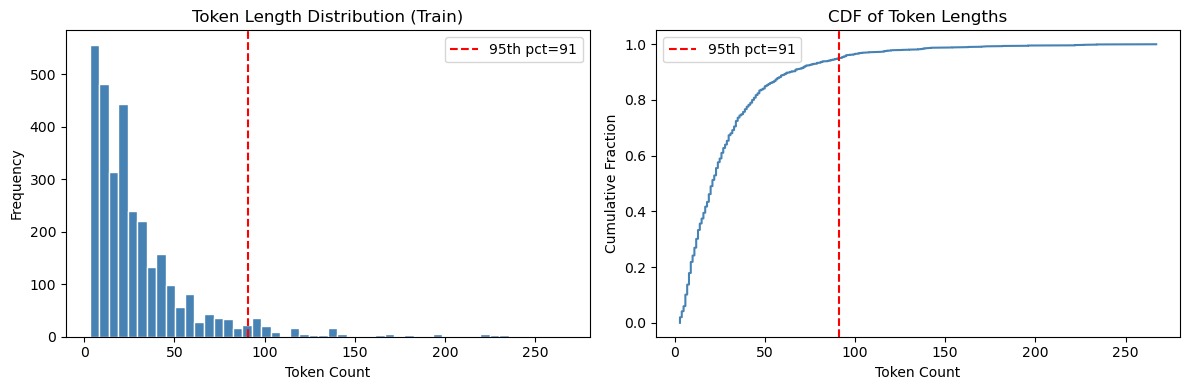

Plot saved.


In [16]:
# ── 11a. Whitespace token counts (fast, always available) ────────────────────
all_lengths = train_df['token_count'].values

percentiles = {p: int(np.percentile(all_lengths, p)) for p in [50, 75, 90, 95, 99]}
rec_max_len = percentiles[95]
print("Token length percentiles (whitespace tokens):")
for p, v in percentiles.items():
    print(f"  {p}th: {v}")
print(f"\nRecommended max_length (95th pct): {rec_max_len}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(all_lengths, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(rec_max_len, color='red', linestyle='--', label=f'95th pct={rec_max_len}')
axes[0].set_title('Token Length Distribution (Train)')
axes[0].set_xlabel('Token Count'); axes[0].set_ylabel('Frequency')
axes[0].legend()

# CDF
sorted_lens = np.sort(all_lengths)
cdf = np.arange(1, len(sorted_lens)+1) / len(sorted_lens)
axes[1].plot(sorted_lens, cdf, color='steelblue')
axes[1].axvline(rec_max_len, color='red', linestyle='--', label=f'95th pct={rec_max_len}')
axes[1].set_title('CDF of Token Lengths')
axes[1].set_xlabel('Token Count'); axes[1].set_ylabel('Cumulative Fraction')
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'token_length_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [17]:
# ── 11b. Transformer Tokenizer Analysis (optional) ───────────────────────────
if TRANSFORMERS_OK:
    try:
        tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
        sample_texts = train_df['clean_text'].dropna().sample(min(500, len(train_df)), random_state=42).tolist()
        tok_lengths  = [len(tokenizer.encode(t, add_special_tokens=True, truncation=False))
                        for t in sample_texts]
        tok_pcts = {p: int(np.percentile(tok_lengths, p)) for p in [50, 75, 90, 95, 99]}
        rec_tok_max = tok_pcts[95]
        print(f"Tokenizer: {TOKENIZER_NAME}")
        print("Subword token length percentiles (sample of 500):")
        for p, v in tok_pcts.items():
            print(f"  {p}th: {v}")
        print(f"Recommended max_length: {rec_tok_max}")
        percentiles.update({'tok_' + str(k): v for k, v in tok_pcts.items()})
        percentiles['recommended_max_length_tokens'] = rec_tok_max
    except Exception as e:
        print(f"Could not load tokenizer ({e}). Using whitespace counts only.")
        tokenizer = None
else:
    tokenizer = None

# Save stats
stats_out = {
    'whitespace_percentiles': percentiles,
    'recommended_max_length': rec_max_len,
    'total_train_rows': len(train_df),
}
with open(os.path.join(OUTPUT_DIR, 'token_length_stats.json'), 'w', encoding='utf-8') as f:
    json.dump(stats_out, f, indent=2, ensure_ascii=False)
print("Saved token_length_stats.json")

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (569 > 512). Running this sequence through the model will result in indexing errors


Tokenizer: aubmindlab/bert-base-arabertv02
Subword token length percentiles (sample of 500):
  50th: 30
  75th: 50
  90th: 94
  95th: 124
  99th: 246
Recommended max_length: 124
Saved token_length_stats.json


## 12. Special Token Registration

In [22]:
if TRANSFORMERS_OK and tokenizer is not None:
    from transformers import AutoModelForSequenceClassification

    special_tokens = ['[ASPECT]']
    n_added = tokenizer.add_special_tokens({'additional_special_tokens': special_tokens})
    print(f"Added {n_added} special token(s): {special_tokens}")
    print(f"New vocab size: {len(tokenizer)}")

    # Demonstrate encoding
    sample = train_fa['input_text'].iloc[0] if 'input_text' in train_fa.columns else train_df['clean_text'].iloc[0]
    encoded = tokenizer(sample, truncation=True, max_length=128)
    print(f"\nSample encoded (first 20 token IDs):\n{encoded['input_ids'][:20]}")
    print(f"Decoded back: {tokenizer.decode(encoded['input_ids'][:20])}")

    # NOTE: To resize model embeddings use:
    # model = AutoModelForSequenceClassification.from_pretrained(TOKENIZER_NAME, ...)
    # model.resize_token_embeddings(len(tokenizer))
    print("\nReminder: call model.resize_token_embeddings(len(tokenizer)) after loading the model.")
else:
    print("Skipped – transformers not available or tokenizer failed to load.")

Added 0 special token(s): ['[ASPECT]']
New vocab size: 64001

Sample encoded (first 20 token IDs):
[2, 64000, 70, 30369, 68, 74, 263, 53797, 26128, 179, 16668, 3, 391, 2741, 8184, 25152, 1102, 195, 690, 56694]
Decoded back: [CLS] [ASPECT] app _ experience [SEP] لا يوجد الدفع بالبطاقه عند الاستلام

Reminder: call model.resize_token_embeddings(len(tokenizer)) after loading the model.


## 13. JSON Submission Skeleton (Unlabeled)

In [23]:
KNOWN_ASPECTS = ['food', 'service', 'ambiance', 'price', 'cleanliness',
                 'delivery', 'app_experience', 'general', 'none']

def make_submission_skeleton(df):
    skeleton = []
    for _, row in df.iterrows():
        skeleton.append({
            "id": str(row['review_id']),
            "review_text": row.get('clean_text', row.get('review_text', '')),
            "aspects": []   # to be filled with {"category": "...", "sentiment": "..."}
        })
    return skeleton

skeleton = make_submission_skeleton(unlabeled_df)
print(f"Skeleton entries: {len(skeleton)}")
print("Sample entry:")
print(json.dumps(skeleton[0], ensure_ascii=False, indent=2))

with open(os.path.join(OUTPUT_DIR, 'submission_skeleton.json'), 'w', encoding='utf-8') as f:
    json.dump(skeleton, f, ensure_ascii=False, indent=2)
print("Saved submission_skeleton.json")

Skeleton entries: 5045
Sample entry:
{
  "id": "1",
  "review_text": "Incroyablement grand avec des belles boutiques et 8 étages complet. J'ai passé journée là tout est propre même les toilettes",
  "aspects": []
}
Saved submission_skeleton.json


## 14. Final Summary

In [24]:
print("=" * 55)
print("  PREPROCESSING PIPELINE COMPLETE")
print("=" * 55)

output_files = [
    'clean_train.csv', 'clean_val.csv', 'clean_unlabeled.csv',
    'train_FormatA.csv', 'train_FormatB.csv',
    'val_FormatA.csv',   'val_FormatB.csv',
    'token_length_stats.json', 'flagged_inconsistent.csv',
    'submission_skeleton.json',
]

print(f"\nOutput files in ./{OUTPUT_DIR}/")
print("-" * 40)
for fname in output_files:
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(fpath):
        size = os.path.getsize(fpath)
        print(f"  ✓  {fname:<35}  {size:>8,} bytes")
    else:
        print(f"  ✗  {fname:<35}  (not created)")

print()
print("Dataset summary:")
print(f"  Train rows      : {len(train_df):>6,}")
print(f"  Validation rows : {len(val_df):>6,}")
print(f"  Unlabeled rows  : {len(unlabeled_df):>6,}")
print(f"  Flagged rows    : {len(flagged_df):>6,}")
print(f"  Rec. max_length : {rec_max_len:>6} tokens (95th pct)")

  PREPROCESSING PIPELINE COMPLETE

Output files in ./output/
----------------------------------------
  ✓  clean_train.csv                      2,485,124 bytes
  ✓  clean_val.csv                         580,338 bytes
  ✓  clean_unlabeled.csv                  1,895,046 bytes
  ✓  train_FormatA.csv                    3,469,364 bytes
  ✓  train_FormatB.csv                    3,580,277 bytes
  ✓  val_FormatA.csv                       806,086 bytes
  ✓  val_FormatB.csv                       833,741 bytes
  ✓  token_length_stats.json                   317 bytes
  ✓  flagged_inconsistent.csv              140,582 bytes
  ✓  submission_skeleton.json             1,075,832 bytes

Dataset summary:
  Train rows      :  3,113
  Validation rows :    782
  Unlabeled rows  :  5,045
  Flagged rows    :    164
  Rec. max_length :     91 tokens (95th pct)
